In [3]:
# معرفة عدد الصفوف والأعمدة
print(f"حجم البيانات الكلي: {master_df.shape}")

# عرض أول 5 صفوف من الداتا عشان نشوف شكلها
master_df.head()

حجم البيانات الكلي: (112650, 26)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_item_id,product_id,...,customer_city,customer_state,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,1,87285b34884572647811a353c7ac498a,...,sao paulo,SP,utilidades_domesticas,40.0,268.0,4.0,500.0,19.0,8.0,13.0
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,1,595fac2a385ac33a80bd5114aec74eb8,...,barreiras,BA,perfumaria,29.0,178.0,1.0,400.0,19.0,13.0,19.0
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,1,aa4383b373c6aca5d8797843e5594415,...,vianopolis,GO,automotivo,46.0,232.0,1.0,420.0,24.0,19.0,21.0
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00,1,d0b61bfb1de832b15ba9d266ca96e5b0,...,sao goncalo do amarante,RN,pet_shop,59.0,468.0,3.0,450.0,30.0,10.0,20.0
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00,1,65266b2da20d04dbe00c5c2d3bb7859e,...,santo andre,SP,papelaria,38.0,316.0,4.0,250.0,51.0,15.0,15.0


In [2]:
# 1. دمج جدول الطلبات مع تفاصيل الطلبات باستخدام رقم الطلب
master_df = pd.merge(df_orders, df_items, on='order_id', how='inner')

# 2. دمج الناتج مع جدول العملاء باستخدام رقم العميل
master_df = pd.merge(master_df, df_customers, on='customer_id', how='inner')

# 3. دمج الناتج مع جدول المنتجات باستخدام رقم المنتج
master_df = pd.merge(master_df, df_products, on='product_id', how='inner')

print("تم دمج الجداول بنجاح في جدول واحد (master_df)!")

تم دمج الجداول بنجاح في جدول واحد (master_df)!


In [4]:
# 1. فحص القيم المفقودة (Missing Values)
print("القيم المفقودة في كل عمود:")
print(master_df.isnull().sum())
print("-" * 40)

# 2. فحص الصفوف المكررة (Duplicates)
print(f"عدد الصفوف المكررة بالكامل: {master_df.duplicated().sum()}")
print("-" * 40)

# 3. فحص أنواع البيانات (Data Types)
print("أنواع البيانات لكل عمود:")
print(master_df.dtypes)

القيم المفقودة في كل عمود:
order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                  15
order_delivered_carrier_date     1194
order_delivered_customer_date    2454
order_estimated_delivery_date       0
order_item_id                       0
product_id                          0
seller_id                           0
shipping_limit_date                 0
price                               0
freight_value                       0
customer_unique_id                  0
customer_zip_code_prefix            0
customer_city                       0
customer_state                      0
product_category_name            1603
product_name_lenght              1603
product_description_lenght       1603
product_photos_qty               1603
product_weight_g                   18
product_length_cm                  18
product_height_cm                  18
product_width_cm       

In [5]:
# 1. تعبئة تصنيفات المنتجات المفقودة بكلمة 'Unknown'
master_df['product_category_name'] = master_df['product_category_name'].fillna('Unknown')

# 2. حذف الطلبات اللي ما اتسلمت للعملاء النهائيين (القيم المفقودة في تاريخ التسليم)
master_df = master_df.dropna(subset=['order_delivered_customer_date'])

# 3. تحويل أعمدة التواريخ من نصوص إلى صيغة تواريخ (DateTime)
date_columns = [
    'order_purchase_timestamp', 
    'order_approved_at',
    'order_delivered_carrier_date', 
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
]

for col in date_columns:
    master_df[col] = pd.to_datetime(master_df[col])

# 4. التأكد من النتيجة النهائية
print("تم تنظيف البيانات بنجاح! ✨")
print(f"حجم البيانات بعد التنظيف: {master_df.shape}")

تم تنظيف البيانات بنجاح! ✨
حجم البيانات بعد التنظيف: (110196, 26)


In [1]:
import pandas as pd

# قراءة الجداول الأربعة الأساسية من ملفات الـ CSV
df_orders = pd.read_csv('olist_orders_dataset.csv')
df_items = pd.read_csv('olist_order_items_dataset.csv')
df_customers = pd.read_csv('olist_customers_dataset.csv')
df_products = pd.read_csv('olist_products_dataset.csv')

print("تمت قراءة البيانات بنجاح! 🚀")

تمت قراءة البيانات بنجاح! 🚀


In [6]:
# 1. Feature Engineering: حساب مدة التوصيل بالأيام
master_df['delivery_time_days'] = (master_df['order_delivered_customer_date'] - master_df['order_purchase_timestamp']).dt.days

# 2. الإحصاء الوصفي (المتوسط، الوسيط، الحد الأدنى والأعلى)
print("الإحصاء الوصفي للأسعار، تكاليف الشحن، ومدة التوصيل:")
summary_stats = master_df[['price', 'freight_value', 'delivery_time_days']].describe().round(2)
print(summary_stats)
print("-" * 40)

# 3. حساب إجمالي الإيرادات (Total Revenue)
total_revenue = master_df['price'].sum()
print(f"إجمالي إيرادات المبيعات المحققة: ${total_revenue:,.2f}")

الإحصاء الوصفي للأسعار، تكاليف الشحن، ومدة التوصيل:
           price  freight_value  delivery_time_days
count  110196.00      110196.00           110196.00
mean      119.98          19.95               12.01
std       182.30          15.70                9.45
min         0.85           0.00                0.00
25%        39.90          13.08                6.00
50%        74.90          16.26               10.00
75%       134.17          21.15               15.00
max      6735.00         409.68              209.00
----------------------------------------
إجمالي إيرادات المبيعات المحققة: $13,220,895.11


In [7]:
# 1. تحليل الإيرادات حسب الولاية (Top 5 States by Revenue)
state_revenue = master_df.groupby('customer_state')['price'].sum().sort_values(ascending=False).head(5)

print("أعلى 5 ولايات تحقيقاً للإيرادات:")
# تنسيق الأرقام عشان تظهر كعملة واضحة
print(state_revenue.apply(lambda x: f"${x:,.2f}"))
print("-" * 40)

# 2. تحليل المنتجات الأكثر مبيعاً (Top 10 Product Categories by Revenue)
top_products = master_df.groupby('product_category_name')['price'].sum().sort_values(ascending=False).head(10)

print("أعلى 10 تصنيفات منتجات تحقيقاً للإيرادات:")
print(top_products.apply(lambda x: f"${x:,.2f}"))

أعلى 5 ولايات تحقيقاً للإيرادات:
customer_state
SP    $5,066,672.78
RJ    $1,760,022.52
MG    $1,552,511.82
RS      $728,718.47
PR      $666,063.51
Name: price, dtype: str
----------------------------------------
أعلى 10 تصنيفات منتجات تحقيقاً للإيرادات:
product_category_name
beleza_saude              $1,233,211.61
relogios_presentes        $1,165,898.98
cama_mesa_banho           $1,023,434.76
esporte_lazer               $954,695.05
informatica_acessorios      $888,613.62
moveis_decoracao            $711,927.69
utilidades_domesticas       $615,628.69
cool_stuff                  $610,204.10
automotivo                  $578,849.35
brinquedos                  $471,197.48
Name: price, dtype: str


In [8]:
# 1. قراءة ملف الترجمة
df_translation = pd.read_csv('product_category_name_translation.csv')

# 2. دمج الترجمة مع الجدول الأساسي (master_df)
master_df = pd.merge(master_df, df_translation, on='product_category_name', how='left')

# عشان التصنيفات اللي سميناها "Unknown" ما حتكون في ملف الترجمة، حنملأ الفراغ بتاعها برضه بـ 'Unknown'
master_df['product_category_name_english'] = master_df['product_category_name_english'].fillna('Unknown')

# 3. حفظ الداتا النهائية والنظيفة في ملف CSV جديد
master_df.to_csv('cleaned_ecommerce_data.csv', index=False)

print("تم دمج الترجمة الإنجليزية بنجاح! 🌍")
print("تم حفظ الداتا النظيفة في ملف (cleaned_ecommerce_data.csv) 🚀")

# عرض عينة صغيرة للتأكد من الترجمة
master_df[['product_category_name', 'product_category_name_english']].head()

تم دمج الترجمة الإنجليزية بنجاح! 🌍
تم حفظ الداتا النظيفة في ملف (cleaned_ecommerce_data.csv) 🚀


,product_category_name,product_category_name_english
0,utilidades_domesticas,housewares
1,perfumaria,perfumery
2,automotivo,auto
3,pet_shop,pet_shop
4,papelaria,stationery


مصفوفة الارتباط (بالأرقام):
                    price  freight_value  delivery_time_days
price                1.00           0.41                0.06
freight_value        0.41           1.00                0.21
delivery_time_days   0.06           0.21                1.00
----------------------------------------


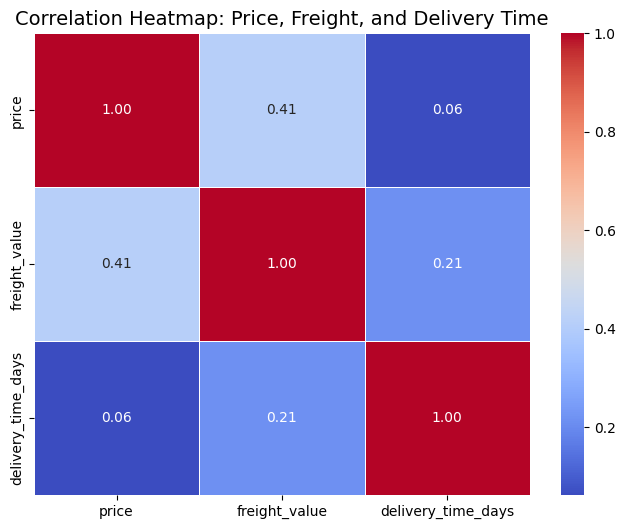

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. تحديد الأعمدة الرقمية اللي عايزين ندرس العلاقة بيناتها
cols_to_analyze = ['price', 'freight_value', 'delivery_time_days']

# 2. حساب مصفوفة الارتباط (Correlation Matrix)
corr_matrix = master_df[cols_to_analyze].corr()

print("مصفوفة الارتباط (بالأرقام):")
print(corr_matrix.round(2))
print("-" * 40)

# 3. رسم الخريطة الحرارية (Heatmap)
plt.figure(figsize=(8, 6)) # تحديد حجم الرسمة
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)

# إضافة عنوان للرسمة
plt.title('Correlation Heatmap: Price, Freight, and Delivery Time', fontsize=14)

# عرض الرسمة
plt.show()